In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series as fpppy_plot_series

import matplotlib.figure
matplotlib.figure.Figure.show = lambda self, *a, **k: None

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [2]:
import statsmodels.api as sm
from scipy.stats import pearsonr
from statsmodels.graphics.tsaplots import plot_acf

In [3]:
df = pd.DataFrame({
    "Year": list(range(2015, 2020)),
    "Observation": [123, 39, 78, 52, 110]
})

In [4]:
print(df.index)
print(df.columns)

RangeIndex(start=0, stop=5, step=1)
Index(['Year', 'Observation'], dtype='str')


In [5]:
df.dtypes

Year           int64
Observation    int64
dtype: object

In [6]:
print(type(df['Year']))
print(df['Year'])

<class 'pandas.Series'>
0    2015
1    2016
2    2017
3    2018
4    2019
Name: Year, dtype: int64


In [7]:
year_df = df.set_index("Year")
year_df

,Observation
Year,
2015,123
2016,39
2017,78
2018,52
2019,110


## Timestamps and Periods

In [8]:
print(repr(pd.Timestamp("2020-01")))
print(repr(pd.Period("2020-01")))

Timestamp('2020-01-01 00:00:00')
Period('2020-01', 'M')


In [9]:
print(repr(pd.Timestamp("2020-01-23")))
print(repr(pd.Timestamp("2020-02")))
print(repr(pd.Timestamp("2023")))

Timestamp('2020-01-23 00:00:00')
Timestamp('2020-02-01 00:00:00')
Timestamp('2023-01-01 00:00:00')


In [10]:
print(repr(pd.Period("2020")))
print(repr(pd.Period("2023-02")))
print(repr(pd.Period("2021-03-01")))

Period('2020', 'Y-DEC')
Period('2023-02', 'M')
Period('2021-03-01', 'D')


### Time Series

#### `pd.to_datetime()` and `pd.date_range()`

In [11]:
ts_few = pd.to_datetime(["2020-01-01", "2020-01-02", "2020-01-03"])
ts_range = pd.date_range(start="2021-02-01", end="2021-03-02", freq="2h")

print(ts_few)
print(ts_range)

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03'], dtype='datetime64[us]', freq=None)
DatetimeIndex(['2021-02-01 00:00:00', '2021-02-01 02:00:00',
               '2021-02-01 04:00:00', '2021-02-01 06:00:00',
               '2021-02-01 08:00:00', '2021-02-01 10:00:00',
               '2021-02-01 12:00:00', '2021-02-01 14:00:00',
               '2021-02-01 16:00:00', '2021-02-01 18:00:00',
               ...
               '2021-03-01 06:00:00', '2021-03-01 08:00:00',
               '2021-03-01 10:00:00', '2021-03-01 12:00:00',
               '2021-03-01 14:00:00', '2021-03-01 16:00:00',
               '2021-03-01 18:00:00', '2021-03-01 20:00:00',
               '2021-03-01 22:00:00', '2021-03-02 00:00:00'],
              dtype='datetime64[us]', length=349, freq='2h')


In [12]:
print(ts_range.to_period())
print(ts_range.to_period(freq='D'))
print(ts_range.to_period(freq='W'))
print(ts_range.to_period().to_timestamp())

PeriodIndex(['2021-02-01 00:00', '2021-02-01 02:00', '2021-02-01 04:00',
             '2021-02-01 06:00', '2021-02-01 08:00', '2021-02-01 10:00',
             '2021-02-01 12:00', '2021-02-01 14:00', '2021-02-01 16:00',
             '2021-02-01 18:00',
             ...
             '2021-03-01 06:00', '2021-03-01 08:00', '2021-03-01 10:00',
             '2021-03-01 12:00', '2021-03-01 14:00', '2021-03-01 16:00',
             '2021-03-01 18:00', '2021-03-01 20:00', '2021-03-01 22:00',
             '2021-03-02 00:00'],
            dtype='period[2h]', length=349)
PeriodIndex(['2021-02-01', '2021-02-01', '2021-02-01', '2021-02-01',
             '2021-02-01', '2021-02-01', '2021-02-01', '2021-02-01',
             '2021-02-01', '2021-02-01',
             ...
             '2021-03-01', '2021-03-01', '2021-03-01', '2021-03-01',
             '2021-03-01', '2021-03-01', '2021-03-01', '2021-03-01',
             '2021-03-01', '2021-03-02'],
            dtype='period[D]', length=349)
PeriodIndex(['2

In [13]:
print(ts_few.strftime("%m/%d/%Y"))
print(ts_range.to_period().strftime("%Y %b ~ %H:%M"))

Index(['01/01/2020', '01/02/2020', '01/03/2020'], dtype='str')
Index(['2021 Feb ~ 00:00', '2021 Feb ~ 02:00', '2021 Feb ~ 04:00',
       '2021 Feb ~ 06:00', '2021 Feb ~ 08:00', '2021 Feb ~ 10:00',
       '2021 Feb ~ 12:00', '2021 Feb ~ 14:00', '2021 Feb ~ 16:00',
       '2021 Feb ~ 18:00',
       ...
       '2021 Mar ~ 06:00', '2021 Mar ~ 08:00', '2021 Mar ~ 10:00',
       '2021 Mar ~ 12:00', '2021 Mar ~ 14:00', '2021 Mar ~ 16:00',
       '2021 Mar ~ 18:00', '2021 Mar ~ 20:00', '2021 Mar ~ 22:00',
       '2021 Mar ~ 00:00'],
      dtype='str', length=349)


In [14]:
df = pd.DataFrame({"ts": ts_few})
df = df.assign(
    period=df["ts"].dt.to_period(),
    yr=df['ts'].dt.year,
    str=df['ts'].dt.strftime("%A, %B %-d"),
).set_index("ts")

In [15]:
df

,period,yr,str
ts,,,
2020-01-01,2020-01-01,2020,"Wednesday, January 1"
2020-01-02,2020-01-02,2020,"Thursday, January 2"
2020-01-03,2020-01-03,2020,"Friday, January 3"


### On actual Data

In [16]:
import sys
from pathlib import Path

In [17]:
cwd = Path.cwd()
project_root = cwd.parent
project_root

PosixPath('/Users/ak007/Projects/TS')

In [18]:
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done!")

Done!


In [19]:
oly_data_path = project_root / "data" / "olympic_running_unparsed.csv"

oly_data = pd.read_csv(oly_data_path)
oly_data.head(8)

,Year,Length,Sex,Time
0,1896,100,men,12.0
1,1900,100,men,11.0
2,1904,100,men,11.0
3,1908,100,men,10.8
4,1912,100,men,10.8
5,1916,100,men,NaN
6,1920,100,men,10.8
7,1924,100,men,10.6


In [20]:
oly_data['Sex'].unique()

<ArrowStringArray>
['men', 'women']
Length: 2, dtype: str

There are 14 Seperate Time Series 

In [21]:
oly_data[['Length', 'Sex']].drop_duplicates()

,Length,Sex
0,100,men
31,100,women
54,200,men
84,200,women
102,400,men
133,400,women
147,800,men
178,800,women
201,1500,men
232,1500,women


### Working with time series dataframes

In [22]:
pbs_data_path = project_root / 'data' / 'PBS_unparsed.csv'
pbs_data = (
    pd.read_csv(pbs_data_path, parse_dates=["Month"])
    [["Month", "Concession", "Type", "ATC1", "ATC2", "Scripts", "Cost"]]
)

In [23]:
pbs_data

,Month,Concession,Type,ATC1,ATC2,Scripts,Cost
0,1991-07-01,Concessional,Co-payments,A,A01,18228,67877.0
1,1991-08-01,Concessional,Co-payments,A,A01,15327,57011.0
2,1991-09-01,Concessional,Co-payments,A,A01,14775,55020.0
3,1991-10-01,Concessional,Co-payments,A,A01,15380,57222.0
4,1991-11-01,Concessional,Co-payments,A,A01,14371,52120.0
...,...,...,...,...,...,...,...
67591,2008-02-01,General,Safety net,Z,Z,135,1591.0
67592,2008-03-01,General,Safety net,Z,Z,15,276.0
67593,2008-04-01,General,Safety net,Z,Z,11,165.0
67594,2008-05-01,General,Safety net,Z,Z,21,278.0


In [24]:
a10 = pbs_data.loc[pbs_data['ATC2'] == 'A10']
a10

,Month,Concession,Type,ATC1,ATC2,Scripts,Cost
1524,1991-07-01,Concessional,Co-payments,A,A10,89733,2.093e+06
1525,1991-08-01,Concessional,Co-payments,A,A10,77101,1.796e+06
1526,1991-09-01,Concessional,Co-payments,A,A10,76255,1.777e+06
1527,1991-10-01,Concessional,Co-payments,A,A10,78681,1.849e+06
1528,1991-11-01,Concessional,Co-payments,A,A10,70554,1.686e+06
...,...,...,...,...,...,...,...
52339,2008-02-01,General,Safety net,A,A10,10869,5.307e+05
52340,2008-03-01,General,Safety net,A,A10,1119,5.177e+04
52341,2008-04-01,General,Safety net,A,A10,721,3.629e+04
52342,2008-05-01,General,Safety net,A,A10,1947,1.012e+05


In [25]:
a10 = (
    pbs_data.loc[pbs_data['ATC2'] == 'A10']
    .drop(columns=["ATC1", "ATC2"])    
)
a10

,Month,Concession,Type,Scripts,Cost
1524,1991-07-01,Concessional,Co-payments,89733,2.093e+06
1525,1991-08-01,Concessional,Co-payments,77101,1.796e+06
1526,1991-09-01,Concessional,Co-payments,76255,1.777e+06
1527,1991-10-01,Concessional,Co-payments,78681,1.849e+06
1528,1991-11-01,Concessional,Co-payments,70554,1.686e+06
...,...,...,...,...,...
52339,2008-02-01,General,Safety net,10869,5.307e+05
52340,2008-03-01,General,Safety net,1119,5.177e+04
52341,2008-04-01,General,Safety net,721,3.629e+04
52342,2008-05-01,General,Safety net,1947,1.012e+05


`.agg()`

In [26]:
total_cost_df = (
    pbs_data.loc[pbs_data['ATC2'] == 'A10']
    .drop(columns=["ATC1", "ATC2"])
    .groupby("Month", as_index=False)
    .agg({"Cost":"sum"})
    .rename(columns={"Cost":"TotalC"})
)

In [27]:
total_cost_df

,Month,TotalC
0,1991-07-01,3.527e+06
1,1991-08-01,3.181e+06
2,1991-09-01,3.252e+06
3,1991-10-01,3.611e+06
4,1991-11-01,3.566e+06
...,...,...
199,2008-02-01,2.165e+07
200,2008-03-01,1.826e+07
201,2008-04-01,2.311e+07
202,2008-05-01,2.291e+07


`.assign()`

In [28]:
total_cost_df = (
    pbs_data.loc[pbs_data['ATC2'] == 'A10']
    .drop(columns=["ATC1", "ATC2"])
    .groupby("Month", as_index=False)
    .agg({"Cost":'sum'})
    .assign(Cost=lambda x:(x['Cost'] / 1e6).round(2))
)

In [29]:
total_cost_df

,Month,Cost
0,1991-07-01,3.53
1,1991-08-01,3.18
2,1991-09-01,3.25
3,1991-10-01,3.61
4,1991-11-01,3.57
...,...,...
199,2008-02-01,21.65
200,2008-03-01,18.26
201,2008-04-01,23.11
202,2008-05-01,22.91


In [30]:
prison_data_path = project_root / 'data' / 'prison_population.csv'
prison_data = (
    pd.read_csv(prison_data_path, parse_dates=['Date'])
    .rename(columns={"Date": "Quarter"})
    .sort_values(by=["State", "Gender", "Legal", "Indigenous"])
)

prison_data

,Quarter,State,Gender,Legal,Indigenous,Count
0,2005-03-01,ACT,Female,Remanded,ATSI,0
64,2005-06-01,ACT,Female,Remanded,ATSI,1
128,2005-09-01,ACT,Female,Remanded,ATSI,0
192,2005-12-01,ACT,Female,Remanded,ATSI,0
256,2006-03-01,ACT,Female,Remanded,ATSI,1
...,...,...,...,...,...,...
2815,2015-12-01,WA,Male,Sentenced,Non-ATSI,2503
2879,2016-03-01,WA,Male,Sentenced,Non-ATSI,2488
2943,2016-06-01,WA,Male,Sentenced,Non-ATSI,2539
3007,2016-09-01,WA,Male,Sentenced,Non-ATSI,2608


In [31]:
total_cost_df.to_csv(project_root / "processed_data" / 'total_cost.csv')

## Time plots

In [32]:
melsyd_economy_data_path = project_root / 'data' / 'ansett.csv'
plain = pd.read_csv(melsyd_economy_data_path)
plain.head()

,ds,Airports,Class,y
0,1989-07-10,ADL-PER,Business,193
1,1989-07-17,ADL-PER,Business,254
2,1989-07-24,ADL-PER,Business,185
3,1989-07-31,ADL-PER,Business,254
4,1989-08-07,ADL-PER,Business,191


In [33]:
melsyd_economy_data = (
    pd.read_csv(melsyd_economy_data_path, parse_dates=["ds"])
    .loc[lambda x:(x["Airports"] == 'MEL-SYD')
         & (x['Class'] == 'Economy')]
    .rename(columns={'Airports':'unique_id'})
    .assign(y=lambda x:x['y'] / 1000)
)

melsyd_economy_data

,ds,unique_id,Class,y
3881,1987-06-22,MEL-SYD,Economy,20.167
3882,1987-06-29,MEL-SYD,Economy,20.161
3883,1987-07-06,MEL-SYD,Economy,19.993
3884,1987-07-13,MEL-SYD,Economy,20.986
3885,1987-07-20,MEL-SYD,Economy,20.497
...,...,...,...,...
4158,1992-10-19,MEL-SYD,Economy,28.837
4159,1992-10-26,MEL-SYD,Economy,26.548
4160,1992-11-02,MEL-SYD,Economy,27.279
4161,1992-11-09,MEL-SYD,Economy,27.306


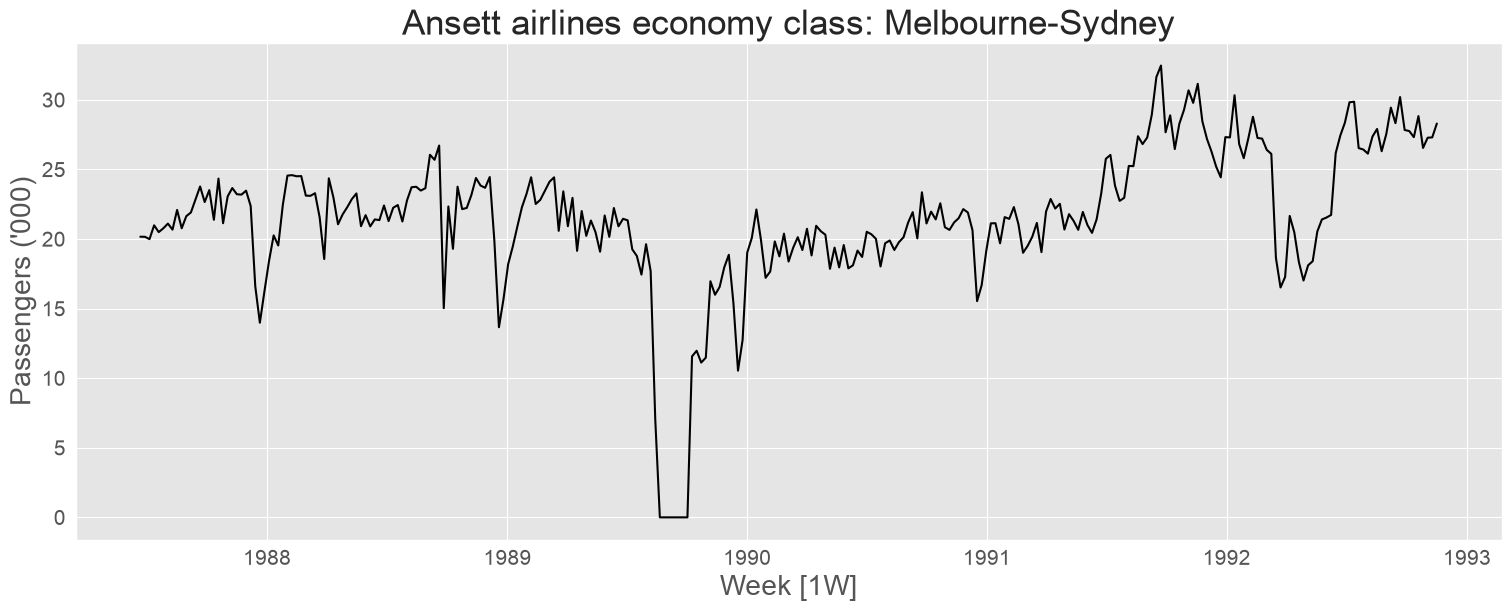

In [34]:
fpppy_plot_series(
    df=melsyd_economy_data, id_col="unique_id", time_col="ds", target_col="y",
    xlabel='Week [1W]', ylabel="Passengers ('000)",
    title='Ansett airlines economy class: Melbourne-Sydney'
)

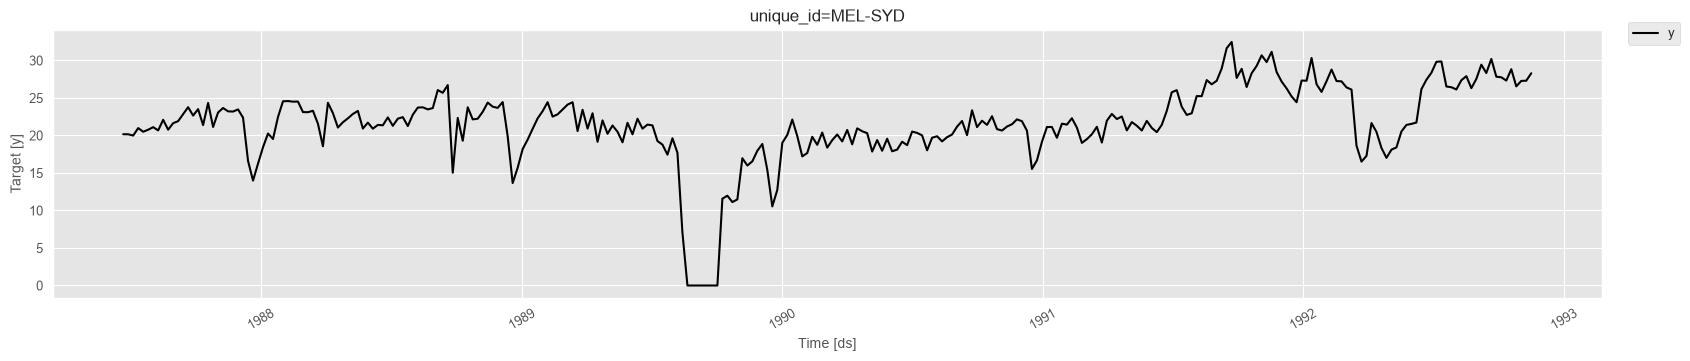

In [35]:
plot_series_utils(
    melsyd_economy_data,
    id_col="unique_id",
    time_col="ds",
    target_col="y"
)

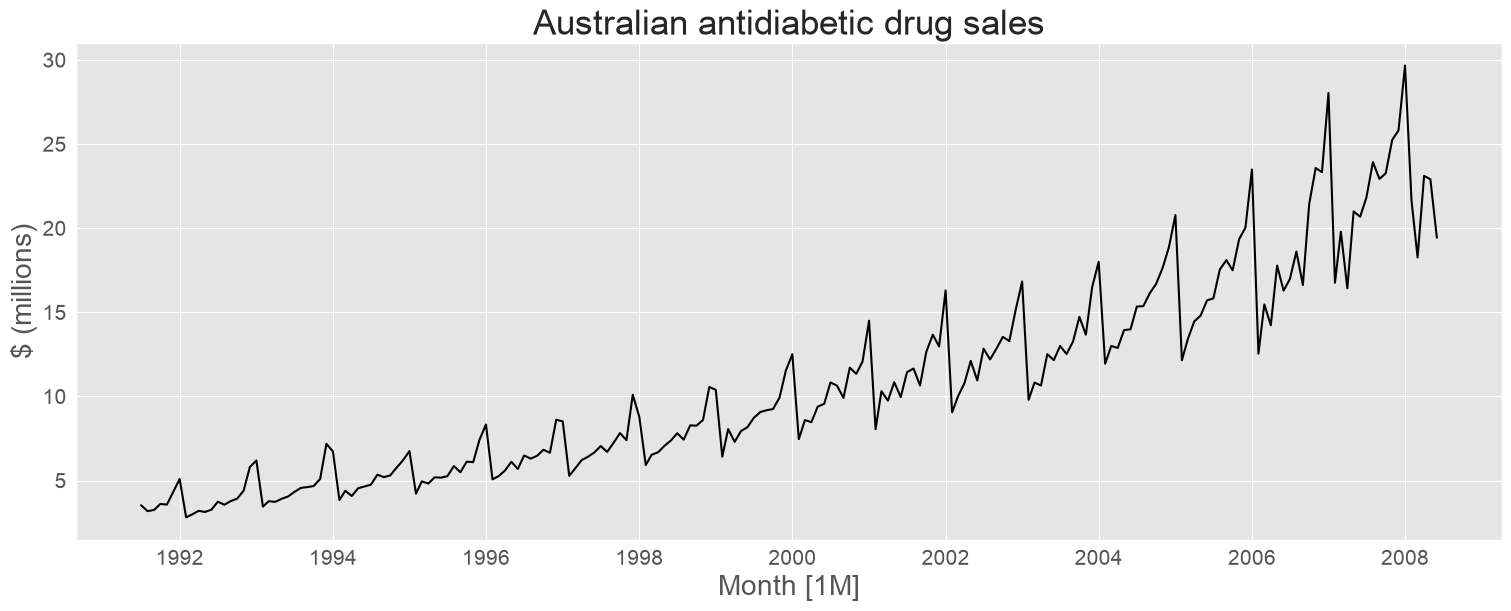

In [36]:
fpppy_plot_series(total_cost_df.assign(unique_id="total_cost"),
    time_col="Month", target_col="Cost",
    xlabel="Month [1M]", ylabel="$ (millions)",
    title="Australian antidiabetic drug sales")

In [37]:
tc_df = total_cost_df.assign(
    Month_name = total_cost_df['Month'].dt.strftime("%b"),
    Year = total_cost_df['Month'].dt.year,
    Month_num = total_cost_df['Month'].dt.month
)

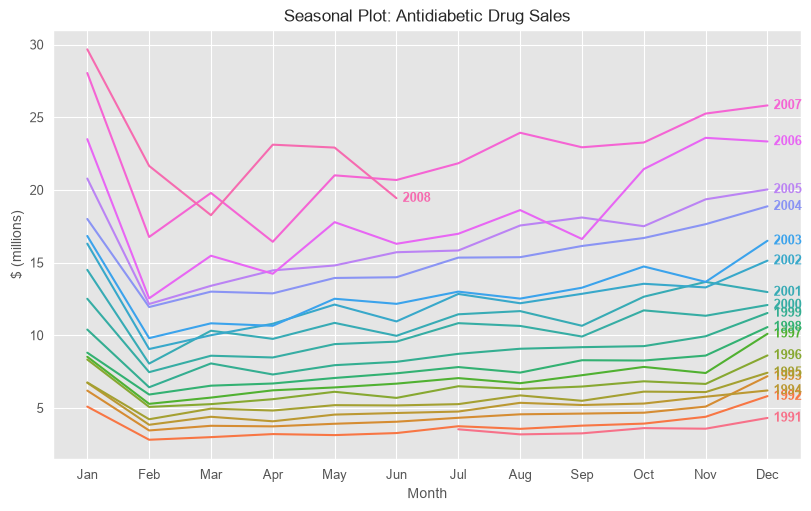

In [38]:
unique_years = tc_df['Year'].unique()
year_palette = sns.color_palette("husl", n_colors=len(unique_years))

fig, ax = plt.subplots()
sns.lineplot(data=tc_df, x="Month_num", y="Cost",
             hue="Year", palette=year_palette, legend=False, ax=ax)

ax.set(
    title="Seasonal Plot: Antidiabetic Drug Sales",
    xlabel="Month",
    ylabel="$ (millions)",
    xticks=range(1, 13),
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ]
)

min_year = unique_years.min()
for year, subset in tc_df.groupby("Year"):
    x = subset['Month_num'].iloc[-1] + .1
    y = subset['Cost'].iloc[-1]
    color = year_palette[year-min_year]
    ax.text(x, y, str(year),
            ha="left", va='center', fontsize=9, weight="bold", color=color)
    
fig.show()

### Multiple seasonal period

In [49]:
vic_elec_data_path = project_root / 'data' / 'vic_elec.csv'
vic_elec_df = pd.read_csv(vic_elec_data_path, parse_dates=["ds"])
vic_elec_demand = vic_elec_df[vic_elec_df["unique_id"] == "Demand"]

In [50]:
df = vic_elec_demand.assign(
    hour_minute = vic_elec_df["ds"].dt.strftime("%H:%M"),
    day = vic_elec_df['ds'].dt.date
)

In [51]:
df

,ds,unique_id,y,Holiday,hour_minute,day
0,2012-01-01 00:00:00,Demand,4382.825,True,00:00,2012-01-01
1,2012-01-01 00:30:00,Demand,4263.366,True,00:30,2012-01-01
2,2012-01-01 01:00:00,Demand,4048.966,True,01:00,2012-01-01
3,2012-01-01 01:30:00,Demand,3877.563,True,01:30,2012-01-01
4,2012-01-01 02:00:00,Demand,4036.230,True,02:00,2012-01-01
...,...,...,...,...,...,...
52597,2014-12-31 21:30:00,Demand,3873.449,False,21:30,2014-12-31
52598,2014-12-31 22:00:00,Demand,3791.637,False,22:00,2014-12-31
52599,2014-12-31 22:30:00,Demand,3724.836,False,22:30,2014-12-31
52600,2014-12-31 23:00:00,Demand,3761.887,False,23:00,2014-12-31


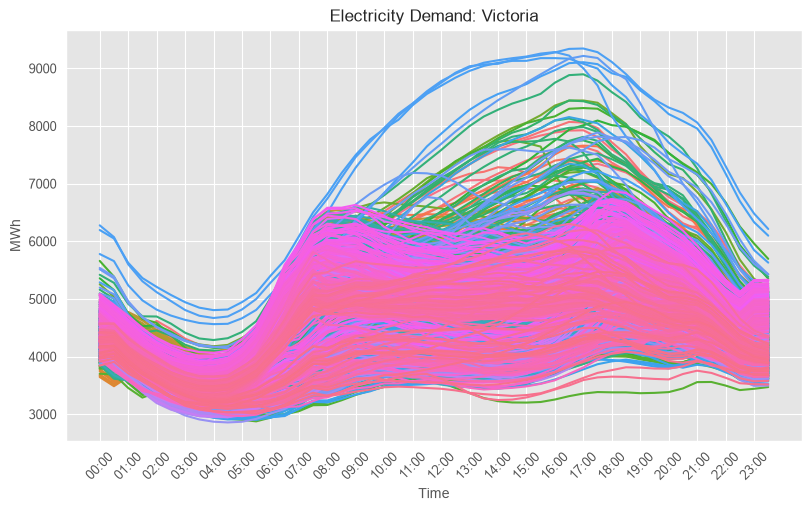

In [52]:
fig, ax = plt.subplots()
sns.lineplot(
    data=df, x="hour_minute", y="y",
    hue="day", palette="husl", legend=False, ax=ax
)

ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh"
)

unique_ticks = df['hour_minute'].unique()
ticks = range(0, len(unique_ticks), 2)
ticklabels = unique_ticks[::2]
ax.set_xticks(ticks=ticks, labels=ticklabels, rotation=45)

fig.show()

In [64]:
# get the shape of the data right
df = (
    vic_elec_demand.loc[lambda x:x["ds"].between("2012-01-02", "2014-12-28 23:59")]
    .assign(
        day_of_week = lambda x:x["ds"].dt.day_name(),
        week = lambda x:x["ds"].dt.to_period("W").dt.start_time,
    )
)

In [62]:
unique_weeks = df["week"].unique()
palette = sns.color_palette("husl", n_colors=len(unique_weeks))
color_map = dict(zip(unique_weeks, palette))

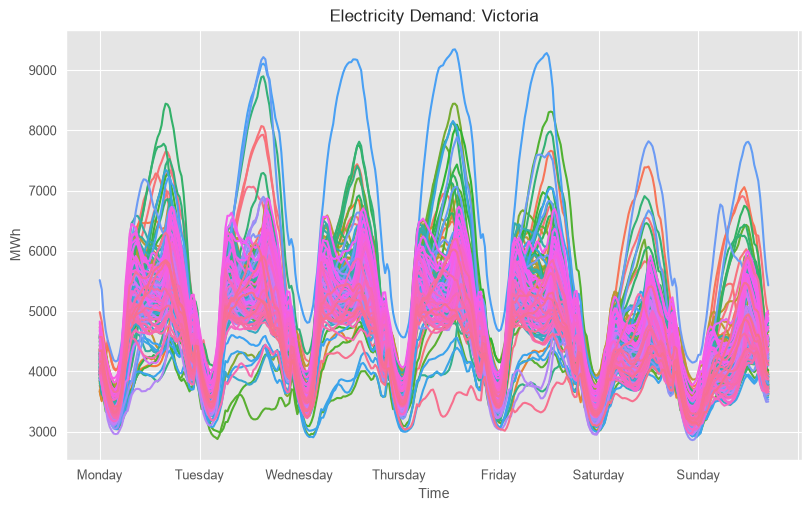

In [65]:
# create the canvas
fig, ax = plt.subplots()

# draw
for week, df_week in df.groupby("week"):
    df_week.plot(x="day_of_week", y="y",
                 ax=ax, color=color_map[week])

# label everything
ax.get_legend().remove()
ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",
)

# render
fig.show()

<Axes: xlabel='day_of_week'>

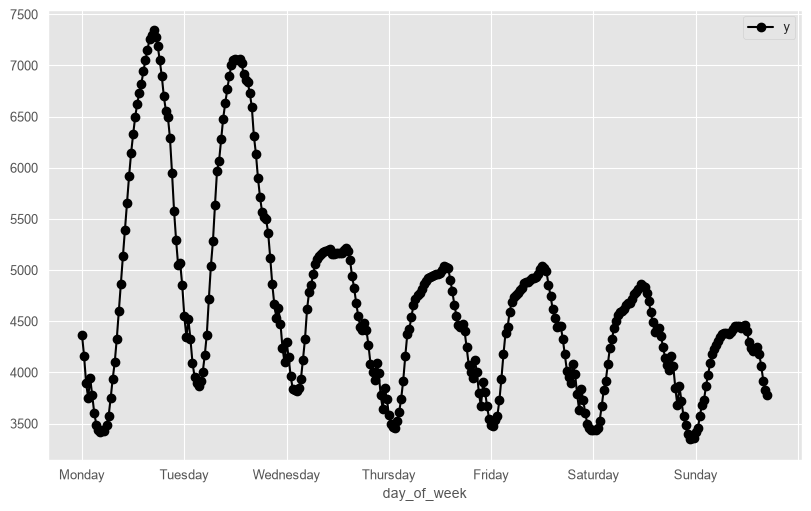

In [66]:
one_week = df[df["week"] == unique_weeks[0]]
fig2, ax2 = plt.subplots()
one_week.plot(x="day_of_week", y="y", ax=ax2, marker="o")

In [67]:
vic_elec_demand

,ds,unique_id,y,Holiday
0,2012-01-01 00:00:00,Demand,4382.825,True
1,2012-01-01 00:30:00,Demand,4263.366,True
2,2012-01-01 01:00:00,Demand,4048.966,True
3,2012-01-01 01:30:00,Demand,3877.563,True
4,2012-01-01 02:00:00,Demand,4036.230,True
...,...,...,...,...
52597,2014-12-31 21:30:00,Demand,3873.449,False
52598,2014-12-31 22:00:00,Demand,3791.637,False
52599,2014-12-31 22:30:00,Demand,3724.836,False
52600,2014-12-31 23:00:00,Demand,3761.887,False


In [68]:
df = vic_elec_demand.assign(
    month_day = lambda x: x["ds"].dt.strftime("%m-%d"),
    year = lambda x: x["ds"].dt.year,
)

In [69]:
df

,ds,unique_id,y,Holiday,month_day,year
0,2012-01-01 00:00:00,Demand,4382.825,True,01-01,2012
1,2012-01-01 00:30:00,Demand,4263.366,True,01-01,2012
2,2012-01-01 01:00:00,Demand,4048.966,True,01-01,2012
3,2012-01-01 01:30:00,Demand,3877.563,True,01-01,2012
4,2012-01-01 02:00:00,Demand,4036.230,True,01-01,2012
...,...,...,...,...,...,...
52597,2014-12-31 21:30:00,Demand,3873.449,False,12-31,2014
52598,2014-12-31 22:00:00,Demand,3791.637,False,12-31,2014
52599,2014-12-31 22:30:00,Demand,3724.836,False,12-31,2014
52600,2014-12-31 23:00:00,Demand,3761.887,False,12-31,2014


In [70]:
unique_years = df['year'].unique()
palette = sns.color_palette(palette="husl", n_colors=len(unique_years))
unique_mon_day = df["month_day"].unique()

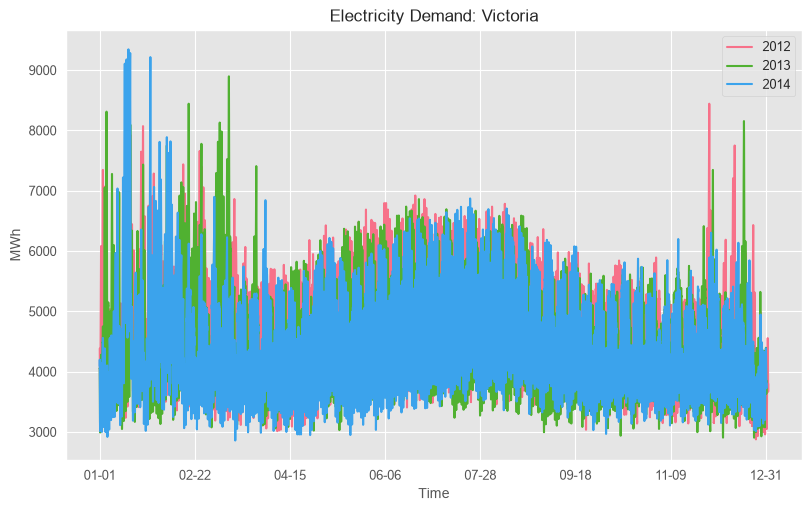

In [72]:
# canvas
fig, ax = plt.subplots()
for i_year, (year, df_year) in enumerate(df.groupby("year")):
    df_year.plot(x="month_day", y="y", ax=ax,
                 label=str(year), color = palette[i_year])
    
ax.set(
    title="Electricity Demand: Victoria",
    ylabel="MWh",
    xlabel="Time"
)

fig.show()